In [ ]:
from google.colab import files
files.upload()

In [ ]:
import pandas as pd
df = pd.read_csv('train.csv')
df.head(5)

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [ ]:
col=['comment_text','toxic']
df=df[col]
df

,comment_text,toxic
0,Explanation\nWhy the edits made under my usern...,0
1,D'aww! He matches this background colour I'm s...,0
2,"Hey man, I'm really not trying to edit war. It...",0
3,"""\nMore\nI can't make any real suggestions on ...",0
4,"You, sir, are my hero. Any chance you remember...",0
...,...,...
159566,""":::::And for the second time of asking, when ...",0
159567,You should be ashamed of yourself \n\nThat is ...,0
159568,"Spitzer \n\nUmm, theres no actual article for ...",0
159569,And it looks like it was actually you who put ...,0


In [ ]:
#converts the text into lower case
df.comment_text=df.comment_text.str.lower()
df

,comment_text,toxic
0,explanation\nwhy the edits made under my usern...,0
1,d'aww! he matches this background colour i'm s...,0
2,"hey man, i'm really not trying to edit war. it...",0
3,"""\nmore\ni can't make any real suggestions on ...",0
4,"you, sir, are my hero. any chance you remember...",0
...,...,...
159566,""":::::and for the second time of asking, when ...",0
159567,you should be ashamed of yourself \n\nthat is ...,0
159568,"spitzer \n\numm, theres no actual article for ...",0
159569,and it looks like it was actually you who put ...,0


In [ ]:
!pip install contractions

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 289.9/289.9 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.3/118.3 kB 14.7 MB/s eta 0:00:00


In [ ]:
import sys
!{sys.executable} -m pip install contractions

In [ ]:
#import library
import contractions

In [ ]:
# Function to expand contractions
def expand_contractions(text):
    if isinstance(text, str):  # Ensure it's a string
        return contractions.fix(text)
    return text  # If not a string, return as-is

In [ ]:
# Modify comment_text column in-place
df["comment_text"] = df["comment_text"].apply(expand_contractions)

In [ ]:
df

,comment_text,toxic
0,explanation\nwhy the edits made under my usern...,0
1,d'aww! he matches this background colour i am ...,0
2,"hey man, i am really not trying to edit war. i...",0
3,"""\nmore\ni cannot make any real suggestions on...",0
4,"you, sir, are my hero. any chance you remember...",0
...,...,...
159566,""":::::and for the second time of asking, when ...",0
159567,you should be ashamed of yourself \n\nthat is ...,0
159568,"spitzer \n\numm, there is no actual article fo...",0
159569,and it looks like it was actually you who put ...,0


In [ ]:
from google.colab import files
files.upload()

Saving slang.csv to slang.csv


{'slang.csv': b',acronym,expansion\n0,2day,today\n1,2m2h,too much too handle\n2,2moro,tomorrow\n3,2nite,tonight\n4,4eae,for ever and ever\n5,aaf,as a friend\n6,aar,at any rate\n7,aayf,as always your friend\n8,abd,already been done\n9,ack,acknowledge\n10,adih,another day in hell\n11,adn,any day now\n12,adr,address\n13,aeap,as early as possible\n14,afaic,as far as i am concerned\n15,afaik,as far as i know\n16,aka,also known as\n17,ama,ask me anything\n18,ambw,all my best wishes\n19,aml,all my love\n20,aota,all of the above\n21,asap,as soon as possible\n22,atb,all the best\n23,ateotd,at the end of the day\n24,atm,at the moment\n25,awol,absent without leave\n26,aydy,are you done yet\n27,ayec,at your earliest convenience\n28,ayor,at your own risk\n29,ays,are you serious\n30,aysos,are you stupid or something\n31,ayt,are you there\n32,b/c,because\n33,b4,before\n34,b4n,bye for now\n35,bau,business as usual\n36,bbiaf,be back in a few\n37,bbiam,be back in a minute\n38,bbias,be back in a sec\n39,

In [ ]:
slang_df = pd.read_csv('slang.csv')

In [ ]:
col_slang=['acronym','expansion']
slang_df=slang_df[col_slang]
slang_df

,acronym,expansion
0,2day,today
1,2m2h,too much too handle
2,2moro,tomorrow
3,2nite,tonight
4,4eae,for ever and ever
...,...,...
3352,yw,you are welcome
3353,ywca,young womens christian association
3354,ywimc,your wish is my command
3355,ywsyls,you win some you lose some


In [ ]:
# Create a dictionary of acronyms and expansions
slang_dict = dict(zip(slang_df['acronym'], slang_df['expansion']))

In [ ]:
# Function to replace acronyms in a text
def replace_acronyms(text):
    words = text.split()
    new_words = []
    for word in words:
        if word in slang_dict:
            new_words.append(slang_dict[word])
        else:
            new_words.append(word)
    return ' '.join(new_words)

In [ ]:
# Apply the function to the comment_text column
df['comment_text'] = df['comment_text'].apply(replace_acronyms)

In [ ]:
df.comment_text[2255]

'no one having objected time out the proposed sections on circumcision fetish and the gilgal fellows, i will assume a consensus, delegate the research, and get back here where in the hell information technology as soon as possible.'

In [ ]:
#tokenize the text ie converts the text intro one gram token ie word wise
import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
df.comment_text=df.comment_text.apply(word_tokenize)
df

,comment_text,toxic
0,"[explanation, why, the, edits, made, under, mi...",0
1,"[d'aww, !, happy, ending, high, explosives, ma...",0
2,"[hey, man, ,, i, ante, meridiem, amplitude, mo...",0
3,"[``, more, i, can, not, make, any, real, sugge...",0
4,"[you, ,, sir, ,, are, miss, you, hero, ., any,...",0
...,...,...
159566,"[``, :, :, :, :, :, and, for, the, second, tea...",0
159567,"[you, should, be, ashamed, of, yourself, that,...",0
159568,"[spitzer, umm, ,, there, is, no, actual, artic...",0
159569,"[and, information, technology, looks, like, in...",0


In [ ]:
#removing all the tokens(words) which are not made of words eg symbols,numbers,emojies etc.
import re
df.comment_text=df.comment_text.apply(lambda x: [word for word in x if re.match('[a-zA-Z]+',word)])
df

,comment_text,toxic
0,"[explanation, why, the, edits, made, under, mi...",0
1,"[d'aww, happy, ending, high, explosives, match...",0
2,"[hey, man, i, ante, meridiem, amplitude, modul...",0
3,"[more, i, can, not, make, any, real, suggestio...",0
4,"[you, sir, are, miss, you, hero, any, chance, ...",0
...,...,...
159566,"[and, for, the, second, tears, in, my, eyes, o...",0
159567,"[you, should, be, ashamed, of, yourself, that,...",0
159568,"[spitzer, umm, there, is, no, actual, article,...",0
159569,"[and, information, technology, looks, like, in...",0


In [ ]:
#Lemmatization tokens [It is the process of reducing a word to its base form by removing endings only
#which is also known as lemma. It was done to get the simplest form of each word
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
lemmatizer=WordNetLemmatizer()
df.comment_text=df.comment_text.apply(lambda x: [lemmatizer.lemmatize(word) for word in x])
df

,comment_text,toxic
0,"[explanation, why, the, edits, made, under, mi...",0
1,"[d'aww, happy, ending, high, explosive, match,...",0
2,"[hey, man, i, ante, meridiem, amplitude, modul...",0
3,"[more, i, can, not, make, any, real, suggestio...",0
4,"[you, sir, are, miss, you, hero, any, chance, ...",0
...,...,...
159566,"[and, for, the, second, tear, in, my, eye, of,...",0
159567,"[you, should, be, ashamed, of, yourself, that,...",0
159568,"[spitzer, umm, there, is, no, actual, article,...",0
159569,"[and, information, technology, look, like, inf...",0


In [ ]:
#removing stopwords
'''
stopwords are frequently used common words like or, and, this, that, etc.
stopwords do not contribute to the knowledge sources and can be removed
'''
from nltk.corpus import stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
df.comment_text=df.comment_text.apply(lambda x: [word for word in x if word not in stopwords.words('english')])
df

In [ ]:
#removing all tokens(word) whose length <2
for i in range(len(df.comment_text)):
  df.comment_text[i]=[word for word in df.comment_text[i] if len(word)>2]
df

Streaming output truncated to the last 5000 lines.
See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df.comment_text[i]=[word for word in df.comment_text[i] if len(word)>2]
<ipython-input-25-dcde940c8387>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.comment_text[i]=[word for word in df.comment_text[i] if len(word)>2]
<ipython-input-25-dcde940c8387>:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we 

,comment_text,toxic
0,"[explanation, edits, made, miss, username, har...",0
1,"[d'aww, happy, ending, high, explosive, match,...",0
2,"[hey, man, ante, meridiem, amplitude, modulati...",0
3,"[make, real, suggestion, improvement, wondered...",0
4,"[sir, miss, hero, chance, remember, page]",0
...,...,...
159566,"[second, tear, eye, asking, view, completely, ...",0
159567,"[ashamed, horrible, thing, put, miss, talk, page]",0
159568,"[spitzer, umm, actual, article, prostitution, ...",0
159569,"[information, technology, look, like, informat...",0


In [ ]:
#clean the pre-process data
for i in range(len(df.comment_text)):
  df.comment_text[i]=' '.join(df.comment_text[i])
df

Streaming output truncated to the last 5000 lines.
See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df.comment_text[i]=' '.join(df.comment_text[i])
<ipython-input-26-a207d2baf701>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.comment_text[i]=' '.join(df.comment_text[i])
<ipython-input-26-a207d2baf701>:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typi

,comment_text,toxic
0,explanation edits made miss username hardcore ...,0
1,d'aww happy ending high explosive match backgr...,0
2,hey man ante meridiem amplitude modulation rea...,0
3,make real suggestion improvement wondered sect...,0
4,sir miss hero chance remember page,0
...,...,...
159566,second tear eye asking view completely contrad...,0
159567,ashamed horrible thing put miss talk page,0
159568,spitzer umm actual article prostitution ring c...,0
159569,information technology look like information t...,0


In [ ]:
'''
End of prepreprocessing
'''

'\nEnd of prepreprocessing\n'

In [ ]:
#!pip install keras.preprocessing.text
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

ERROR: Could not find a version that satisfies the requirement keras.preprocessing.text (from versions: none)
ERROR: No matching distribution found for keras.preprocessing.text


In [ ]:
!wget --no-check-certificate https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip

!unzip glove.6B.zip

--2025-03-19 13:35:11--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2025-03-19 13:35:12--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2025-03-19 13:35:12--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

In [ ]:
# Tokenizing the text data
tokenizer = Tokenizer()
tokenizer.fit_on_texts(df['comment_text'])

In [ ]:
print("Number of unique words in dictionary=", len(tokenizer.word_index))
print("Dictionary sample=", dict(list(tokenizer.word_index.items())[:10]))

Number of unique words in dictionary= 164295
Dictionary sample= {'time': 1, 'information': 2, 'technology': 3, 'see': 4, 'article': 5, 'hell': 6, 'page': 7, 'wait': 8, 'note': 9, 'author': 10}


In [ ]:
# Load GloVe embeddings
def embedding_for_vocab(filepath, word_index, embedding_dim):
    vocab_size = len(word_index) + 1
    embedding_matrix_vocab = np.zeros((vocab_size, embedding_dim))

    with open(filepath, encoding="utf8") as f:
        for line in f:
            word, *vector = line.split()
            if word in word_index:
                idx = word_index[word]
                embedding_matrix_vocab[idx] = np.array(vector, dtype=np.float32)[:embedding_dim]

    return embedding_matrix_vocab

In [ ]:
embedding_dim = 300
glove_path = 'glove.6B.300d.txt'  # Update to the correct filename if needed
embedding_matrix_vocab = embedding_for_vocab(glove_path, tokenizer.word_index, embedding_dim)

In [ ]:
print("Dense vector for first word in vocabulary:", embedding_matrix_vocab[1])

Dense vector for first word in vocabulary: [-0.13544001  0.14539     0.098176    0.027927    0.13773    -0.10157
 -0.077469   -0.088126    0.33730999 -1.6983      0.15218     0.07475
  0.029915    0.051422   -0.0029723   0.12388     0.043299    0.089802
 -0.20465    -0.055862    0.31790999  0.034534    0.29449999 -0.12702
 -0.052015   -0.21604     0.036685    0.010581   -0.41788    -0.057079
 -0.048993    0.35716999  0.16539     0.18861    -1.60510004  0.02282
 -0.11233    -0.040446   -0.14177001  0.31595999  0.39601001 -0.010631
 -0.31988001 -0.12419     0.077703    0.23717     0.48873001  0.51726002
 -0.12604     0.13104001  0.4824     -0.32694    -0.084319   -0.05101
 -0.21287     0.23481999 -0.17468999  0.098685    0.088829    0.10877
  0.2696     -0.16976    -0.059894   -0.10843     0.019634   -0.63300002
 -0.059735    0.14917     0.17865001 -0.20739     0.028565    0.097195
 -0.31524     0.33967999 -0.1019      0.41135001 -0.025738   -0.03429
 -0.19163001 -0.30368    -0.27711999 

In [ ]:
# Split dataset into training and testing
xtrain, xtest, ytrain, ytest = train_test_split(df['comment_text'], df['toxic'], test_size=0.2, random_state=42)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam

# Convert text to sequences
sequences = tokenizer.texts_to_sequences(df['comment_text'])
vocab_size = len(tokenizer.word_index) + 1
maxlen = max([len(seq) for seq in sequences]) # Ensure maxlen is defined

X = pad_sequences(sequences, maxlen=maxlen)
y = df['toxic'].values

# Define CNN model
cnn = Sequential()
cnn.add(layers.Input(shape=(maxlen,)))  # Explicitly define input shape
cnn.add(layers.Embedding(input_dim=vocab_size, output_dim=embedding_dim, weights=[embedding_matrix_vocab], trainable=True))
cnn.add(layers.Dropout(0.5))
cnn.add(layers.Conv1D(filters=64, kernel_size=3, activation='swish', kernel_regularizer=l2(0.01)))
cnn.add(layers.MaxPool1D(pool_size=3))
cnn.add(layers.Dropout(0.5))
cnn.add(layers.Conv1D(filters=64, kernel_size=3, activation='swish', kernel_regularizer=l2(0.01)))
cnn.add(layers.GlobalMaxPool1D())
cnn.add(layers.Dropout(0.5))
cnn.add(layers.Dense(256, activation='swish', kernel_regularizer=l2(0.01)))
cnn.add(layers.Dropout(0.5))
cnn.add(layers.Dense(1, activation='sigmoid'))

# Compile model
cnn.compile(optimizer=Adam(learning_rate=0.0003), loss='binary_crossentropy', metrics=['accuracy'])

# Print summary to verify model is built correctly
cnn.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 3091, 300)           │      49,288,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 3091, 300)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d (Conv1D)                      │ (None, 3089, 64)            │          57,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 1029, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 1029, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 1027, 64)            │          12,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_max_pooling1d                 │ (None, 64)                  │               0 │
│ (GlobalMaxPooling1D)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │          16,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 49,375,713 (188.35 MB)

 Trainable params: 49,375,713 (188.35 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Convert xtrain and xtest to sequences and pad them
xtrain_sequences = tokenizer.texts_to_sequences(xtrain)
xtest_sequences = tokenizer.texts_to_sequences(xtest)

xtrain_padded = pad_sequences(xtrain_sequences, maxlen=maxlen) # Use maxlen from earlier
xtest_padded = pad_sequences(xtest_sequences, maxlen=maxlen)   # Use maxlen from earlier

# Train the model using the padded sequences
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=1, restore_best_weights=True)

epochs = 10
batch_size = 32
history = cnn.fit(xtrain_padded, ytrain,  # Changed to xtrain_padded
                  epochs=epochs,
                  batch_size=batch_size,
                  validation_data=(xtest_padded, ytest)) # Changed to xtest_padded

Epoch 1/10
3990/3990 ━━━━━━━━━━━━━━━━━━━━ 171s 40ms/step - accuracy: 0.8983 - loss: 0.8500 - val_accuracy: 0.9241 - val_loss: 0.2450
Epoch 2/10
3990/3990 ━━━━━━━━━━━━━━━━━━━━ 188s 39ms/step - accuracy: 0.9288 - loss: 0.2408 - val_accuracy: 0.9302 - val_loss: 0.2209
Epoch 3/10
3990/3990 ━━━━━━━━━━━━━━━━━━━━ 159s 40ms/step - accuracy: 0.9350 - loss: 0.2201 - val_accuracy: 0.9428 - val_loss: 0.2040
Epoch 4/10
3990/3990 ━━━━━━━━━━━━━━━━━━━━ 198s 39ms/step - accuracy: 0.9403 - loss: 0.2057 - val_accuracy: 0.9410 - val_loss: 0.2033
Epoch 5/10
3990/3990 ━━━━━━━━━━━━━━━━━━━━ 161s 40ms/step - accuracy: 0.9453 - loss: 0.1915 - val_accuracy: 0.9418 - val_loss: 0.2002
Epoch 6/10
3990/3990 ━━━━━━━━━━━━━━━━━━━━ 197s 39ms/step - accuracy: 0.9456 - loss: 0.1880 - val_accuracy: 0.9440 - val_loss: 0.1942
Epoch 7/10
3990/3990 ━━━━━━━━━━━━━━━━━━━━ 202s 39ms/step - accuracy: 0.9473 - loss: 0.1833 - val_accuracy: 0.9456 - val_loss: 0.1911
Epoch 8/10
3990/3990 ━━━━━━━━━━━━━━━━━━━━ 156s 39ms/step - accuracy: 

In [ ]:
# Evaluate the model
loss, accuracy = cnn.evaluate(xtest_padded, ytest)  # Use xtest_padded instead of xtest
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Loss: {loss:.4f}")

998/998 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9462 - loss: 0.1875
Test Accuracy: 0.9454
Test Loss: 0.1899


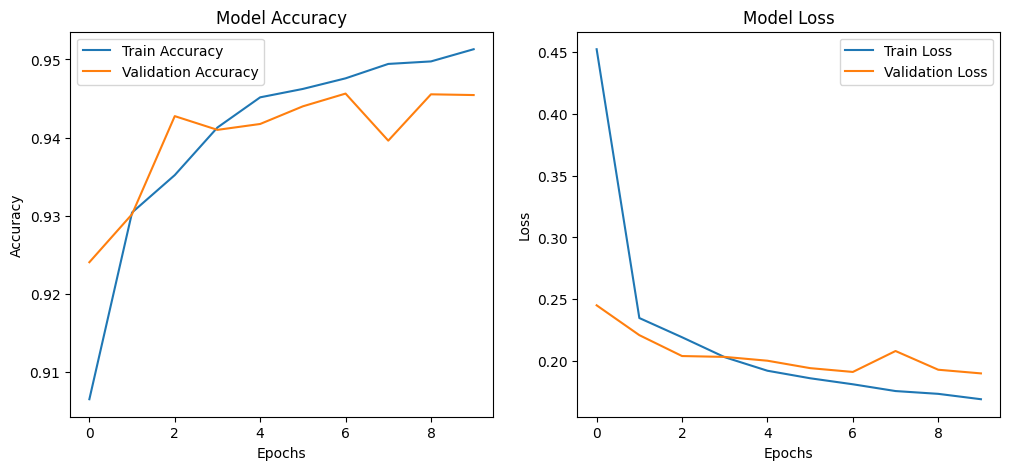

In [ ]:
# Plot accuracy and loss
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()

plt.show()

In [ ]:
ypred=m.predict(x_test)
ypred

In [ ]:
ypred1=ypred.round()
ypred1

In [ ]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
accuracy_score(y_test,ypred1)

In [ ]:
confusion_matrix=confusion_matrix(y_test,ypred1)

In [ ]:
from seaborn import heatmap
heatmap(confusion_matrix,annot=True,cmap='Greens')

In [ ]:
classification_report=classification_report(y_test,ypred1)
print(classification_report)